In [68]:
from model.model import PoseModel
import torch
from data.dataset import LinemodDataset

import cv2
import numpy as np

from utils.predictions import estimate_pose
from utils.visualization import show_all

# Loading the model

In [69]:
checkpoint_path="checkpoints/best.pth"

In [96]:
model = PoseModel(num_objects=15).to("cuda")

    # Carica checkpoint
checkpoint = torch.load(checkpoint_path, map_location="cuda")

    # Carica pesi
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

/home/raciard/.conda/envs/tp3d/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/raciard/.conda/envs/tp3d/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


PoseModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

# Loading the dataset

In [97]:
dataset_root = "datasets/Linemod_preprocessed/"

val_dataset = LinemodDataset(dataset_root, split='test')



# Making a prediction and visualizing the corresponding 3d bb

sample number 2220, 


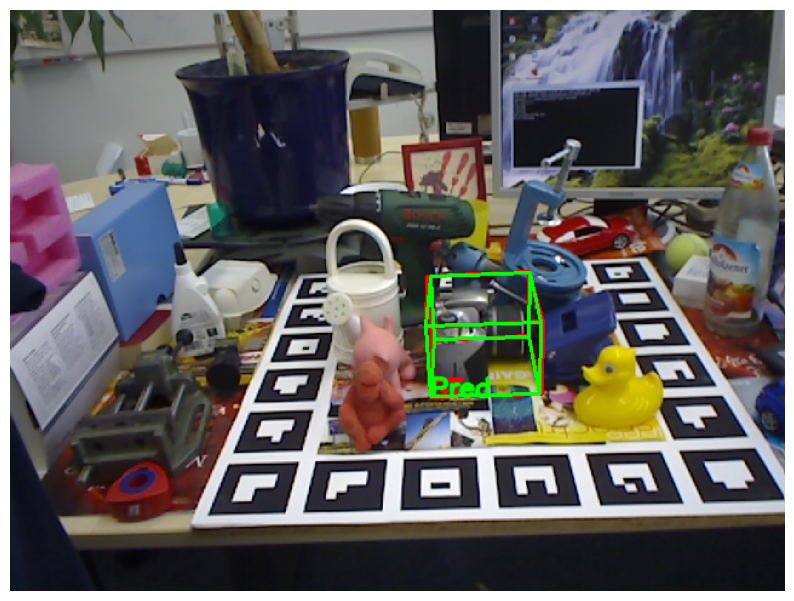

In [198]:
import random
random.seed()
sample_id =random.randint(0,len(val_dataset))
print(f"sample number {sample_id}, ")
pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)







show_all(val_dataset[sample_id], pred_r, pred_t)


In [175]:
import os

In [176]:
def get_3d_model_path(dataset_root, obj_id):
    print(obj_id)
    return os.path.join(dataset_root, 'models', f"obj_{obj_id+1:02d}.ply")

In [177]:
from metrics.add import compute_add, compute_add_percent

In [199]:
sample = val_dataset[sample_id]

In [200]:
model_path = get_3d_model_path(dataset_root,sample['obj_id'])

tensor(3)


In [201]:
compute_add(model_path, sample['rotation'], sample['translation'], pred_r, pred_t)

np.float64(15.360481210807242)

In [202]:
compute_add_percent(model_path, sample['rotation'], sample['translation'], pred_r,pred_t)

(np.float64(15.360481210807242),
 np.float64(93.07728674519512),
 np.float64(221.8852730921067))

In [182]:
from utils.refine_pose import refine_pose
import refiner.refiner
import utils.refine_pose
import importlib
importlib.reload(utils.refine_pose)
importlib.reload(refiner.refiner)

<module 'refiner.refiner' from '/home/raciard/mldl/mldl_project/refiner/refiner.py'>

In [203]:
refined_r, refined_t, losses = refine_pose(model_path, sample, pred_r, pred_t, num_iters=200)

[0/200] Loss: 0.000600
[1/200] Loss: 0.000546
[2/200] Loss: 0.000465
[3/200] Loss: 0.000424
[4/200] Loss: 0.000387
[5/200] Loss: 0.000350
[6/200] Loss: 0.000319
[7/200] Loss: 0.000286
[8/200] Loss: 0.000249
[9/200] Loss: 0.000234
[10/200] Loss: 0.000215
[11/200] Loss: 0.000198
[12/200] Loss: 0.000210
[13/200] Loss: 0.000186
[14/200] Loss: 0.000157
[15/200] Loss: 0.000141
[16/200] Loss: 0.000134
[17/200] Loss: 0.000121
[18/200] Loss: 0.000113
[19/200] Loss: 0.000112
[20/200] Loss: 0.000110
[21/200] Loss: 0.000108
[22/200] Loss: 0.000111
[23/200] Loss: 0.000122
[24/200] Loss: 0.000134
[25/200] Loss: 0.000137
[26/200] Loss: 0.000145
[27/200] Loss: 0.000154
[28/200] Loss: 0.000158
[29/200] Loss: 0.000161
[30/200] Loss: 0.000161
[31/200] Loss: 0.000169
[32/200] Loss: 0.000175
[33/200] Loss: 0.000175
[34/200] Loss: 0.000172
[35/200] Loss: 0.000164
[36/200] Loss: 0.000160
[37/200] Loss: 0.000160
[38/200] Loss: 0.000160
[39/200] Loss: 0.000156
[40/200] Loss: 0.000156
[41/200] Loss: 0.000151
[4

In [107]:
pred_r

array([[-0.24361683, -0.96924613, -0.03482499],
       [-0.72094491,  0.20499204, -0.66197938],
       [ 0.6487598 , -0.13616242, -0.74871257]])

In [108]:
pred_t

array([[ 15.66988064],
       [-65.53124226],
       [780.07123964]])

In [109]:
sample['rotation']

tensor([[-0.2665, -0.9633, -0.0303],
        [-0.7898,  0.2363, -0.5660],
        [ 0.5524, -0.1269, -0.8239]])

In [110]:
sample['translation']

tensor([ 17.1713, -66.4904, 806.6087])

In [111]:
refined_r

tensor([[[-0.2596, -0.9654,  0.0239],
         [-0.7428,  0.1838, -0.6438],
         [ 0.6171, -0.1849, -0.7648]]], device='cuda:0', dtype=torch.float64)

In [112]:
refined_t

tensor([[ 0.0167, -0.0632,  0.8077]], device='cuda:0', dtype=torch.float64)

In [208]:
compute_add_percent(model_path, sample['rotation'], sample['translation'], pred_r, pred_t)

(np.float64(15.360481210807242),
 np.float64(93.07728674519512),
 np.float64(221.8852730921067))

In [209]:
compute_add_percent(model_path, sample['rotation'], sample['translation'], refined_r.cpu().detach().squeeze().numpy(), refined_t.cpu().detach() * 1000)

(np.float64(8.132307774915255),
 np.float64(96.3349042225351),
 np.float64(221.8852730921067))

In [272]:
r_ref = refined_r.cpu().detach().squeeze().numpy()
t_ref = refined_t.cpu().detach().numpy() * 1000

In [ ]:
losses

In [462]:
add_perc_cum = 0
n_ok = 0
n_ok_per_obj = {}
n_tot_per_obj = dict()
for sample_id in range(len(val_dataset)):
    sample = val_dataset[sample_id]
    obj_id = int(sample['obj_id'])
    pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)
    model_path = get_3d_model_path(dataset_root, obj_id)
    refined_r, refined_t, losses = refine_pose(model_path, sample, pred_r, pred_t, num_iters=200)
    r_ref = refined_r.cpu().detach().squeeze().numpy()
    t_ref = refined_t.cpu().detach().numpy() * 1000
    add_abs, add_perc, _ = compute_add_percent(model_path, sample['rotation'], sample['translation'], r_ref, t_ref)
    add_perc_cum = add_perc_cum + add_perc
    if obj_id not in n_tot_per_obj:
        n_tot_per_obj[obj_id] = 0
        n_ok_per_obj[obj_id] = 0

    if add_perc > 90:
        n_ok+=1
        n_ok_per_obj[obj_id] += 1
    n_tot_per_obj[obj_id] +=1
    curr_perc = add_perc_cum / (sample_id + 1)
    curr_ok_perc = n_ok / (sample_id + 1) * 100
    curr_ok_perc_obj = (n_ok_per_obj[obj_id] if obj_id in n_ok_per_obj else 0) / n_tot_per_obj[obj_id] * 100

    print(f"Current add: {curr_perc}%")
    print(f"Current ok perc: {curr_ok_perc}")
    print(f"Current ok perc per obj {obj_id}: {curr_ok_perc_obj}")


    

4
[0/200] Loss: 0.000520
[1/200] Loss: 0.000437
[2/200] Loss: 0.000376
[3/200] Loss: 0.000346
[4/200] Loss: 0.000312
[5/200] Loss: 0.000302
[6/200] Loss: 0.000291
[7/200] Loss: 0.000298
[8/200] Loss: 0.000290
[9/200] Loss: 0.000284
[10/200] Loss: 0.000286
[11/200] Loss: 0.000254
[12/200] Loss: 0.000255
[13/200] Loss: 0.000258
[14/200] Loss: 0.000260
[15/200] Loss: 0.000259
[16/200] Loss: 0.000260
[17/200] Loss: 0.000254
[18/200] Loss: 0.000250
[19/200] Loss: 0.000260
[20/200] Loss: 0.000264
[21/200] Loss: 0.000274
[22/200] Loss: 0.000282
[23/200] Loss: 0.000282
[24/200] Loss: 0.000284
[25/200] Loss: 0.000285
[26/200] Loss: 0.000282
[27/200] Loss: 0.000275
[28/200] Loss: 0.000273
[29/200] Loss: 0.000270
[30/200] Loss: 0.000260
[31/200] Loss: 0.000252
[32/200] Loss: 0.000256
[33/200] Loss: 0.000268
[34/200] Loss: 0.000273
[35/200] Loss: 0.000273
[36/200] Loss: 0.000274
[37/200] Loss: 0.000275
[38/200] Loss: 0.000273
[39/200] Loss: 0.000254
[40/200] Loss: 0.000262
[41/200] Loss: 0.000268


AttributeError: 'NoneType' object has no attribute 'layout'

98.27586206896551

In [464]:
n_ok_per_obj

{4: 56,
 0: 80,
 12: 55,
 13: 39,
 14: 55,
 7: 47,
 8: 57,
 3: 52,
 9: 53,
 10: 31,
 11: 48,
 5: 51}

In [465]:
n_tot_per_obj

{4: 58,
 0: 89,
 12: 58,
 13: 42,
 14: 56,
 7: 47,
 8: 58,
 3: 53,
 9: 56,
 10: 47,
 11: 53,
 5: 51}